In [27]:
import numpy as np 
import matplotlib.pyplot as plt

import sys 
sys.path.append('../../..')

import jax
from functools import partial
from jax import grad, jacfwd, vmap, jit, hessian, value_and_grad
from jax.lax import scan
# from jax.ops import index_update, index
import jax.random as jnp_random
import jax.numpy as np
import jax.debug as deb

from jax.flatten_util import ravel_pytree

import numpy as onp
from time_opt_erg_lib.dynamics import DoubleIntegrator, SingleIntegrator2D

from time_opt_erg_lib.ergodic_metric import ErgodicMetric
from time_opt_erg_lib.obstacle import Obstacle
from time_opt_erg_lib.cbf import constr2CBF
from time_opt_erg_lib.fourier_utils import BasisFunc, get_phik, get_ck
from time_opt_erg_lib.target_distribution import TargetDistribution
from time_opt_erg_lib.cbf_utils import sdf2cbf
from IPython.display import clear_output
import matplotlib.pyplot as plt

from time_opt_erg_lib.opt_solver import AugmentedLagrangeSolver
import yaml
import pickle as pkl

def build_erg_time_opt_solver(init_sol, args, scale, num_basis=10, step_size=1e-3, c=2.):
    basis           = BasisFunc(n_basis=[num_basis]*2)
    erg_metric      = ErgodicMetric(basis)
    robot_model     = DoubleIntegrator()
    n,m = robot_model.n, robot_model.m
    target_distr    = TargetDistribution()
    workspace_bnds = [[0.,1.0*scale],[0.,1.0*scale]]
   
    args.update({
        'phik' : get_phik(target_distr.evals, basis),
    })

    @vmap
    def emap(x):
        """ Function that maps states to workspace """
        return np.array([
            (x[0]-workspace_bnds[0][0])/(workspace_bnds[0][1]-workspace_bnds[0][0]), 
            (x[1]-workspace_bnds[1][0])/(workspace_bnds[1][1]-workspace_bnds[1][0])])
            
    # @jit
    def loss(params, args):
        x = params['x']
        u = params['u']
        tf = params['tf']
        N = args['N']
        dt = tf/N
        e = emap(x)
        """ Traj opt loss function, not the same as erg metric """
        return tf

    def eq_constr(params, args):
        """ dynamic equality constriants """
        x = params['x']
        u = params['u']

        x0 = args['x0']
        xf = args['xf']
        tf = params['tf']
        N = args['N']
        dt = tf/N
        return np.vstack([
            (x[0] - x0)*0, 
            x[1:,:]-(x[:-1,:]+dt*vmap(robot_model.dfdt)(x[:-1,:], u[:-1,:])),
            (x[-1] - xf)*0
        ])

    def ineq_constr(params, args):
        """ inequality constraints"""
        x = params['x']
        u = params['u']
        phik = args['phik']
        tf = params['tf']
        N = args['N']
        dt = tf/N
        e = emap(x)
        ck = get_ck(e, basis, tf, dt)
        _erg_ineq = [np.array([erg_metric(ck, phik) - args['erg_ub'], -tf])]
        _ctrl_box = [(np.abs(u) - 1.).flatten()]
        _expl_box = [(-e).flatten(), (e-1.0).flatten()]
        return np.concatenate(_erg_ineq + _ctrl_box + _expl_box)

    solver = AugmentedLagrangeSolver(
                    init_sol,
                    loss, 
                    eq_constr, 
                    ineq_constr, 
                    args, 
                    step_size=step_size,
                    c=c)
    return solver


# Scale Results

In [28]:
np.linalg.norm((np.ones_like(sol['u'])*np.sqrt(2))**2)

Array(14.142135, dtype=float32)

done in  5896  iterations


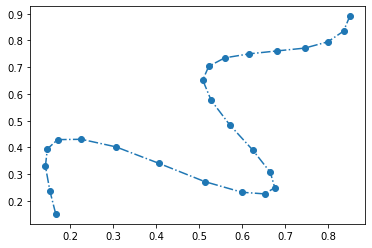

0.8100617 4.2271705
done in  5893  iterations


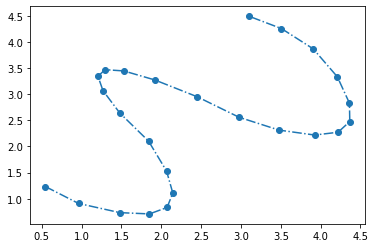

4.0503087 6.0694566
done in  6481  iterations


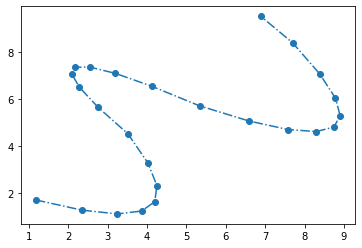

8.100617 6.521387
done in  14001  iterations


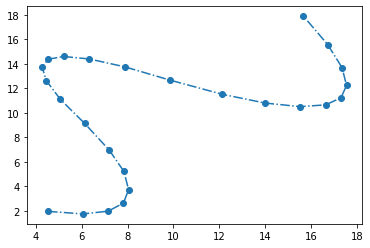

16.201235 6.4497275
unsuccessful, tol:  96.734375


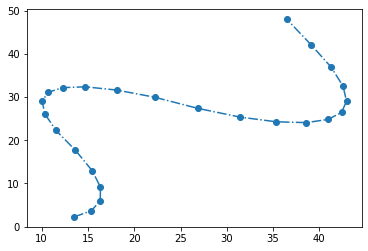

40.503086 6.03996


In [29]:
scales = [1., 5., 10., 20, 50]
# scales = [1.]

for i, scale in enumerate(scales):
    args = {
        'N' : 25, 
        'x0' : np.array([0.1, 0.1, 0., 0.])*scale,
        'xf' : np.array([0.92, 0.9, 0., 0.])*scale,
        'erg_ub' : 0.1,
    }
    x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = np.zeros((args['N'], 2))
    max_time = np.linalg.norm(args['x0']-args['xf'])/np.sqrt(2)
    init_sol = {'x': x, 'u' : u, 'tf': np.array(10.)}
    solver = build_erg_time_opt_solver(init_sol, args, scale=scale)
    solver.solve(max_iter=20_000, eps=1e-6)
    sol = solver.get_solution()
    plt.plot(sol['x'][:,0],sol['x'][:,1], '-.o')
    plt.show()
    print(max_time, np.linalg.norm(sol['u']**2))

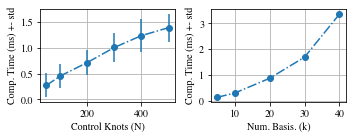

In [21]:
plt.rcParams["font.family"] = "times"

fig, axs = plt.subplots(1, 2, figsize=(5,2))

axs[0].errorbar(knots, np.array(knot_results['avg'])*1e3, yerr=np.array(knot_results['std'])*1e3, fmt='-.o')
axs[0].grid()
axs[0].set_xlabel('Control Knots (N)')
axs[0].set_ylabel('Comp. Time (ms) +- std')


axs[1].errorbar(num_basis, np.array(basis_res['avg'])*1e3, yerr=np.array(basis_res['std'])*1e3, fmt='-.o')
axs[1].grid()
axs[1].set_xlabel('Num. Basis. (k)')
axs[1].set_ylabel('Comp. Time (ms) +- std')

fig.tight_layout()

plt.savefig('additional_comp.pdf')

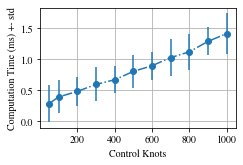

In [23]:
# plt.rcParams["font.family"] = "freeserif"
plt.rcParams["font.family"] = "times"

plt.figure(figsize=(3.5,2.2))
plt.errorbar(knots, np.array(avg_res)*1e3, yerr=np.array(std_res)*1e3, fmt='-.o')
plt.grid()
plt.xlabel('Control Knots')
plt.ylabel('Computation Time (ms) +- std')
# plt.legend()
plt.savefig('comp_anal.pdf')

Text(0, 0.5, 'Computation Time (ms) +- std')

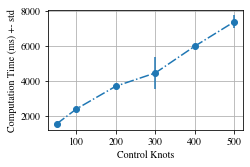

In [28]:
plt.rcParams["font.family"] = "times"

plt.figure(figsize=(3.5,2.2))
plt.errorbar(knots, np.array(avg_res)*1e3, yerr=np.array(std_res)*1e3, fmt='-.o')
plt.grid()
plt.xlabel('Control Knots')
plt.ylabel('Computation Time (ms) +- std')

In [5]:
num_basis = [5, 8, 10, 20, 50, 100]
avg_res = []
std_res = []
for i, _n_basis in enumerate(num_basis):
    args = {
        'N' : 100, 
        'x0' : np.array([0.1, 0.1, 0., 0.]),
        'xf' : np.array([0.9, 0.9, 0., 0.]),
        'erg_ub' : 0.1,
    }
    x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = np.zeros((args['N'], 2))
    init_sol = {'x': x, 'u' : u, 'tf': np.array(10.0)}
    solver = build_erg_time_opt_solver(init_sol, args, num_basis=_n_basis)
    solver.solve(max_iter=1, eps=1e-7)
    _res = %timeit -o solver.solve(max_iter=1, eps=1e-7)
    avg_res.append(_res.average)
    std_res.append(_res.stdev)


126 µs ± 1.52 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
219 µs ± 4.52 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
298 µs ± 6.97 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
850 µs ± 13.1 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.72 ms ± 186 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
10 ms ± 231 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Text(0, 0.5, 'Computation Time (ms) +- std')

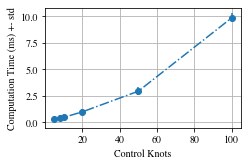

In [4]:
plt.rcParams["font.family"] = "times"

plt.figure(figsize=(3.5,2.2))
plt.errorbar(num_basis, np.array(avg_res)*1e3, yerr=np.array(std_res)*1e3, fmt='-.o')
plt.grid()
plt.xlabel('Control Knots')
plt.ylabel('Computation Time (ms) +- std')

# Scale Result

In [ ]:
knots = [50, 200, 400, 600, 800, 1000]
knot_results = {
    'avg': [],
    'std': []}
for i, knot in enumerate(knots):
    args = {
        'N' : knot, 
        'x0' : np.array([0.1, 0.1, 0., 0.]),
        'xf' : np.array([0.9, 0.9, 0., 0.]),
        'erg_ub' : 0.1,
    }
    x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = np.zeros((args['N'], 2))
    init_sol = {'x': x, 'u' : u, 'tf': np.array(10.0)}
    solver = build_erg_time_opt_solver(init_sol, args)
    _res = %timeit -o solver.solve(max_iter=1, eps=1e-7)
    knot_results['avg'].append(_res.average)
    knot_results['std'].append(_res.stdev)